
Running 6 pairwise comparisons within Mindline


── Rants (n=276) vs Family (n=71) ──
   Chi²=24.67, p=0.1024, dof=17
   Schemas significant after BH: 1/18


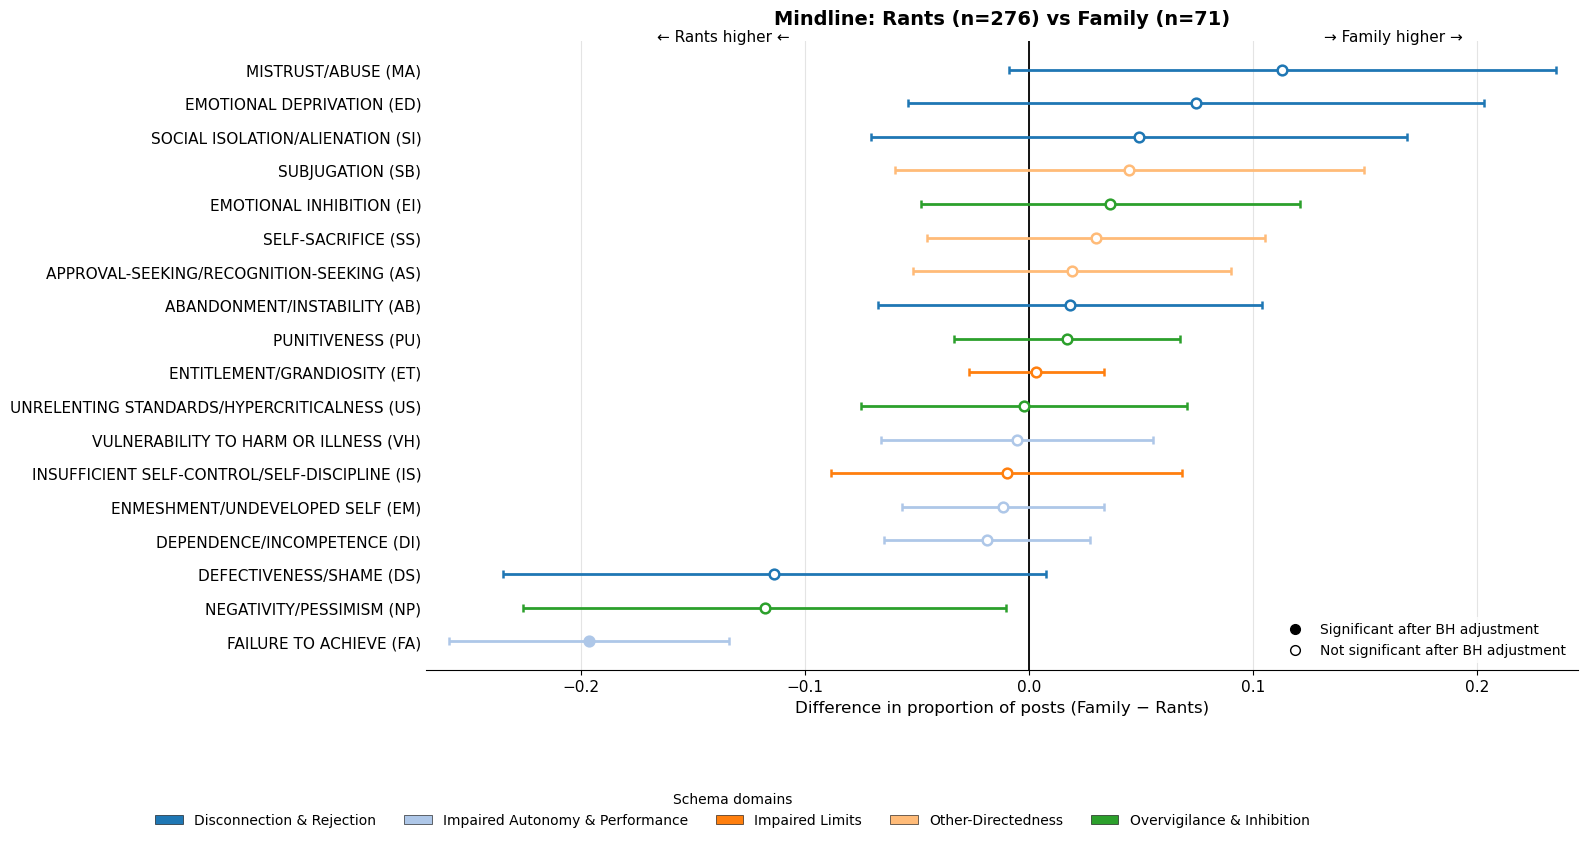

  → saved plots/mindline_topic_comparisons/Rants_vs_Family.png

── Rants (n=276) vs Adulting (n=112) ──
   Chi²=58.97, p=1.555e-06, dof=17
   Schemas significant after BH: 5/18


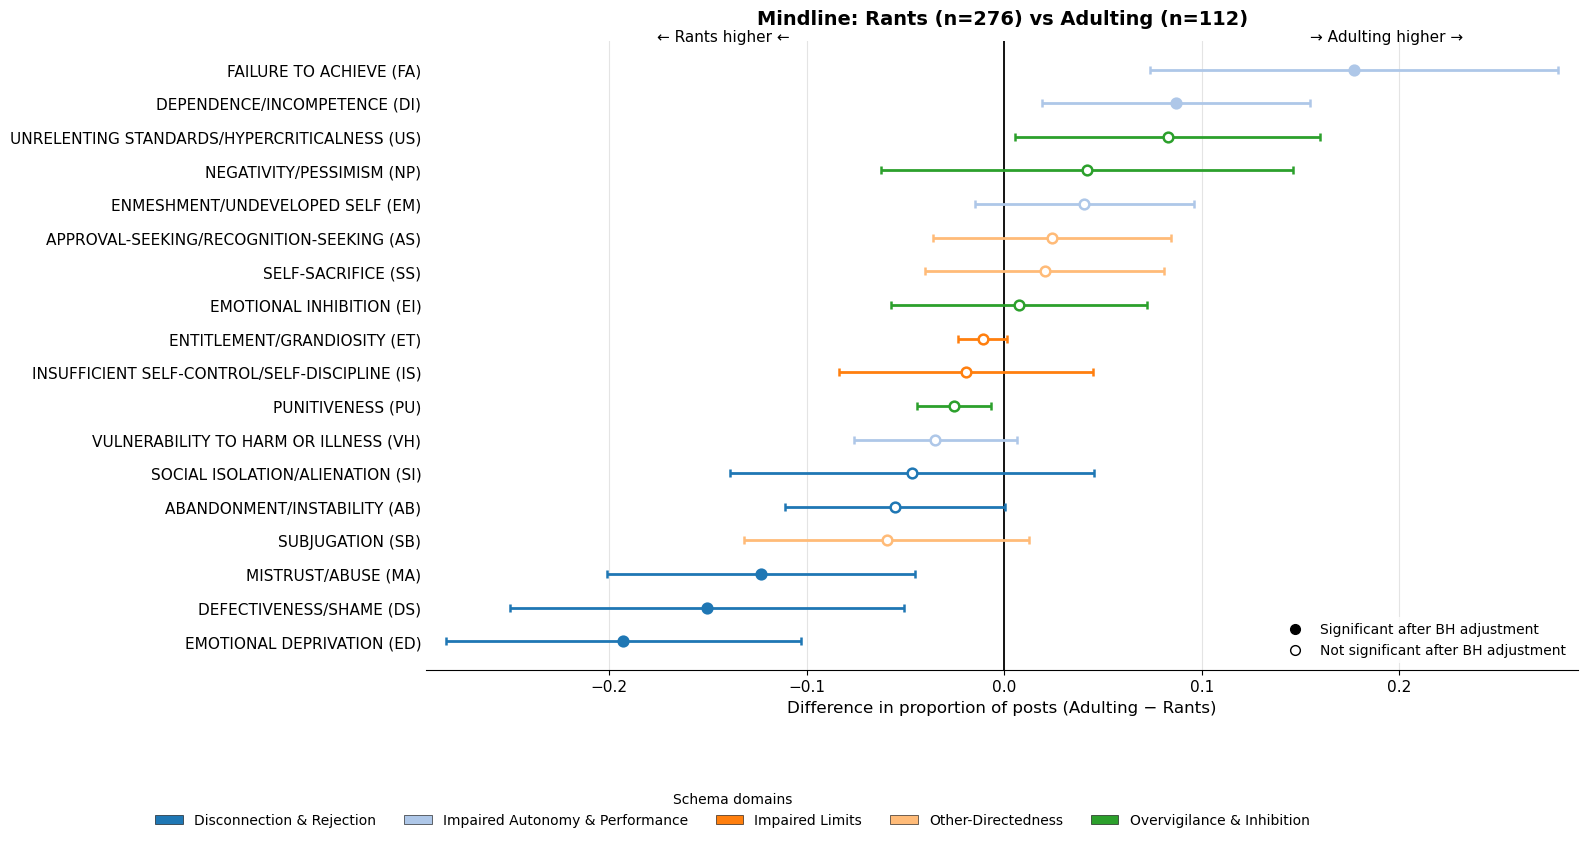

  → saved plots/mindline_topic_comparisons/Rants_vs_Adulting.png

── Rants (n=276) vs Student (n=151) ──
   Chi²=131.94, p=7.924e-20, dof=17
   Schemas significant after BH: 11/18


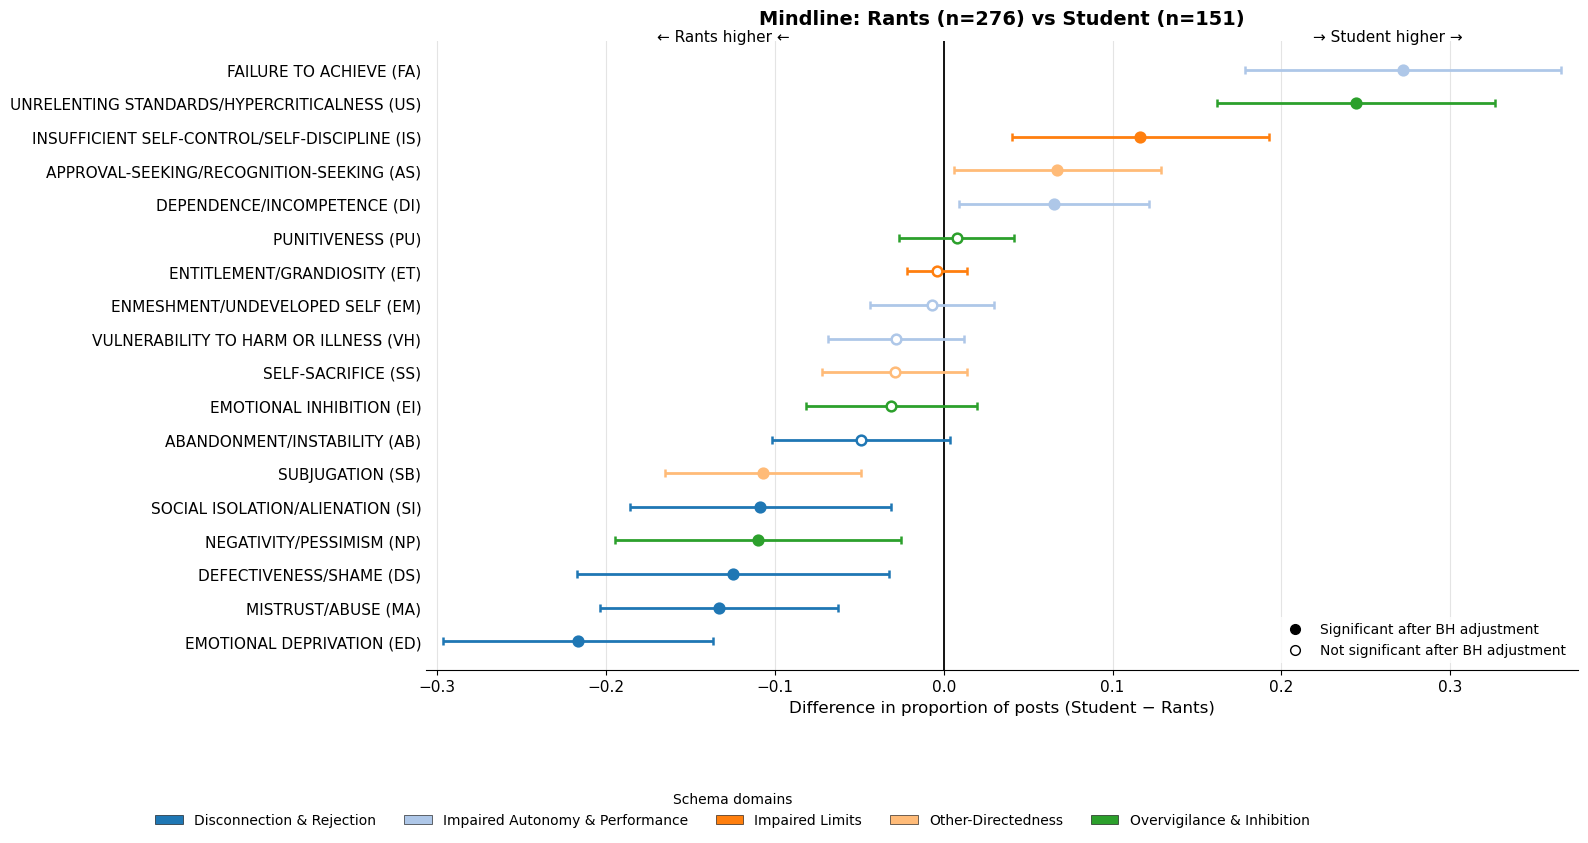

  → saved plots/mindline_topic_comparisons/Rants_vs_Student.png

── Family (n=71) vs Adulting (n=112) ──
   Chi²=73.96, p=4.439e-09, dof=17
   Schemas significant after BH: 3/18


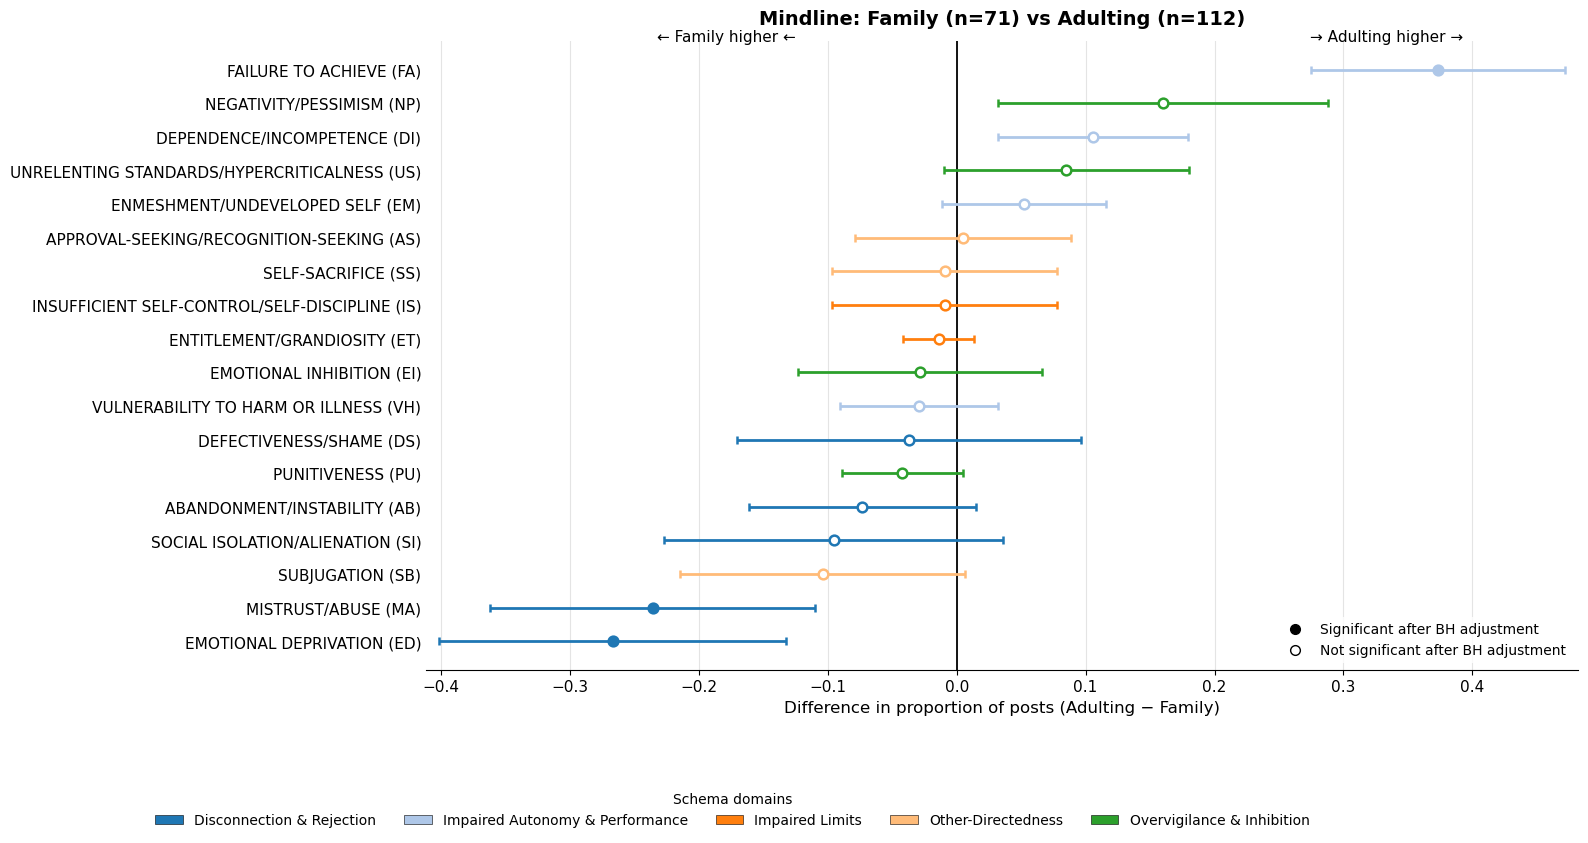

  → saved plots/mindline_topic_comparisons/Family_vs_Adulting.png

── Family (n=71) vs Student (n=151) ──
   Chi²=108.13, p=2.705e-15, dof=17
   Schemas significant after BH: 6/18


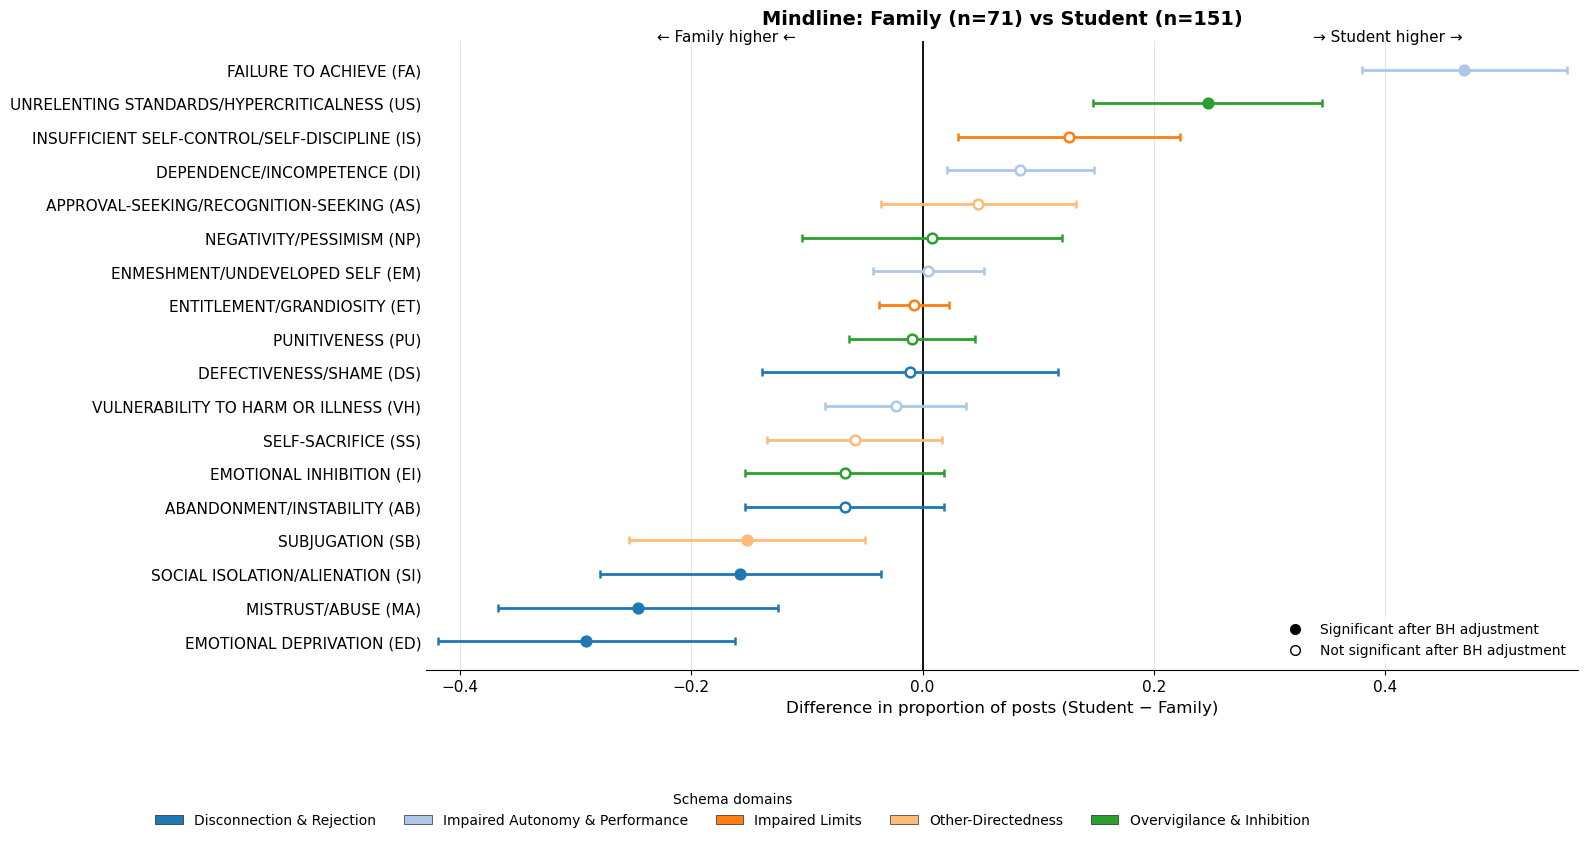

  → saved plots/mindline_topic_comparisons/Family_vs_Student.png

── Adulting (n=112) vs Student (n=151) ──
   Chi²=36.36, p=0.004099, dof=17
   Schemas significant after BH: 3/18


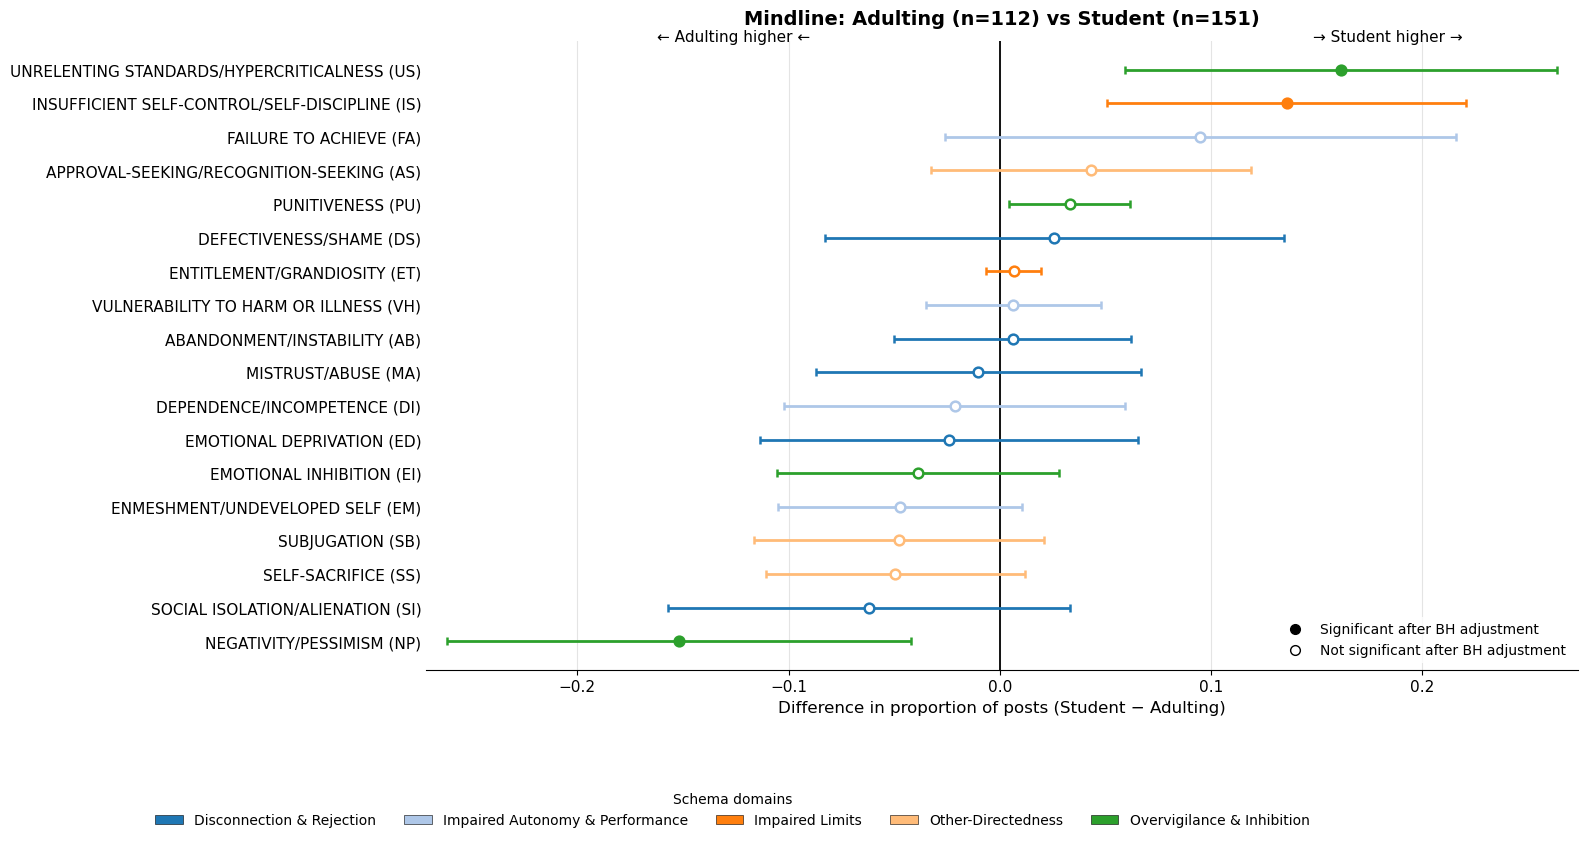

  → saved plots/mindline_topic_comparisons/Adulting_vs_Student.png

All results saved.
  z-tests  → data_for_OSF_upload/results/mindline_topic_pairwise_z_tests.csv
  chi²     → data_for_OSF_upload/results/mindline_topic_pairwise_chi_square.csv
  plots    → plots/mindline_topic_comparisons/


Chi-square omnibus results per pair:
         comparison       Chi2            p  dof
    Rants vs Family  24.667878 1.023942e-01   17
  Rants vs Adulting  58.965687 1.555294e-06   17
   Rants vs Student 131.940139 7.924413e-20   17
 Family vs Adulting  73.960526 4.438556e-09   17
  Family vs Student 108.133952 2.705397e-15   17
Adulting vs Student  36.364844 4.098787e-03   17


Significant schemas per comparison:

Adulting vs Student  (3 significant):
                                        schema      diff         z    p_adj
  UNRELENTING STANDARDS/HYPERCRITICALNESS (US) -0.161483 -2.943586 0.031571
INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS) -0.135880 -2.919322 0.031571
                     N

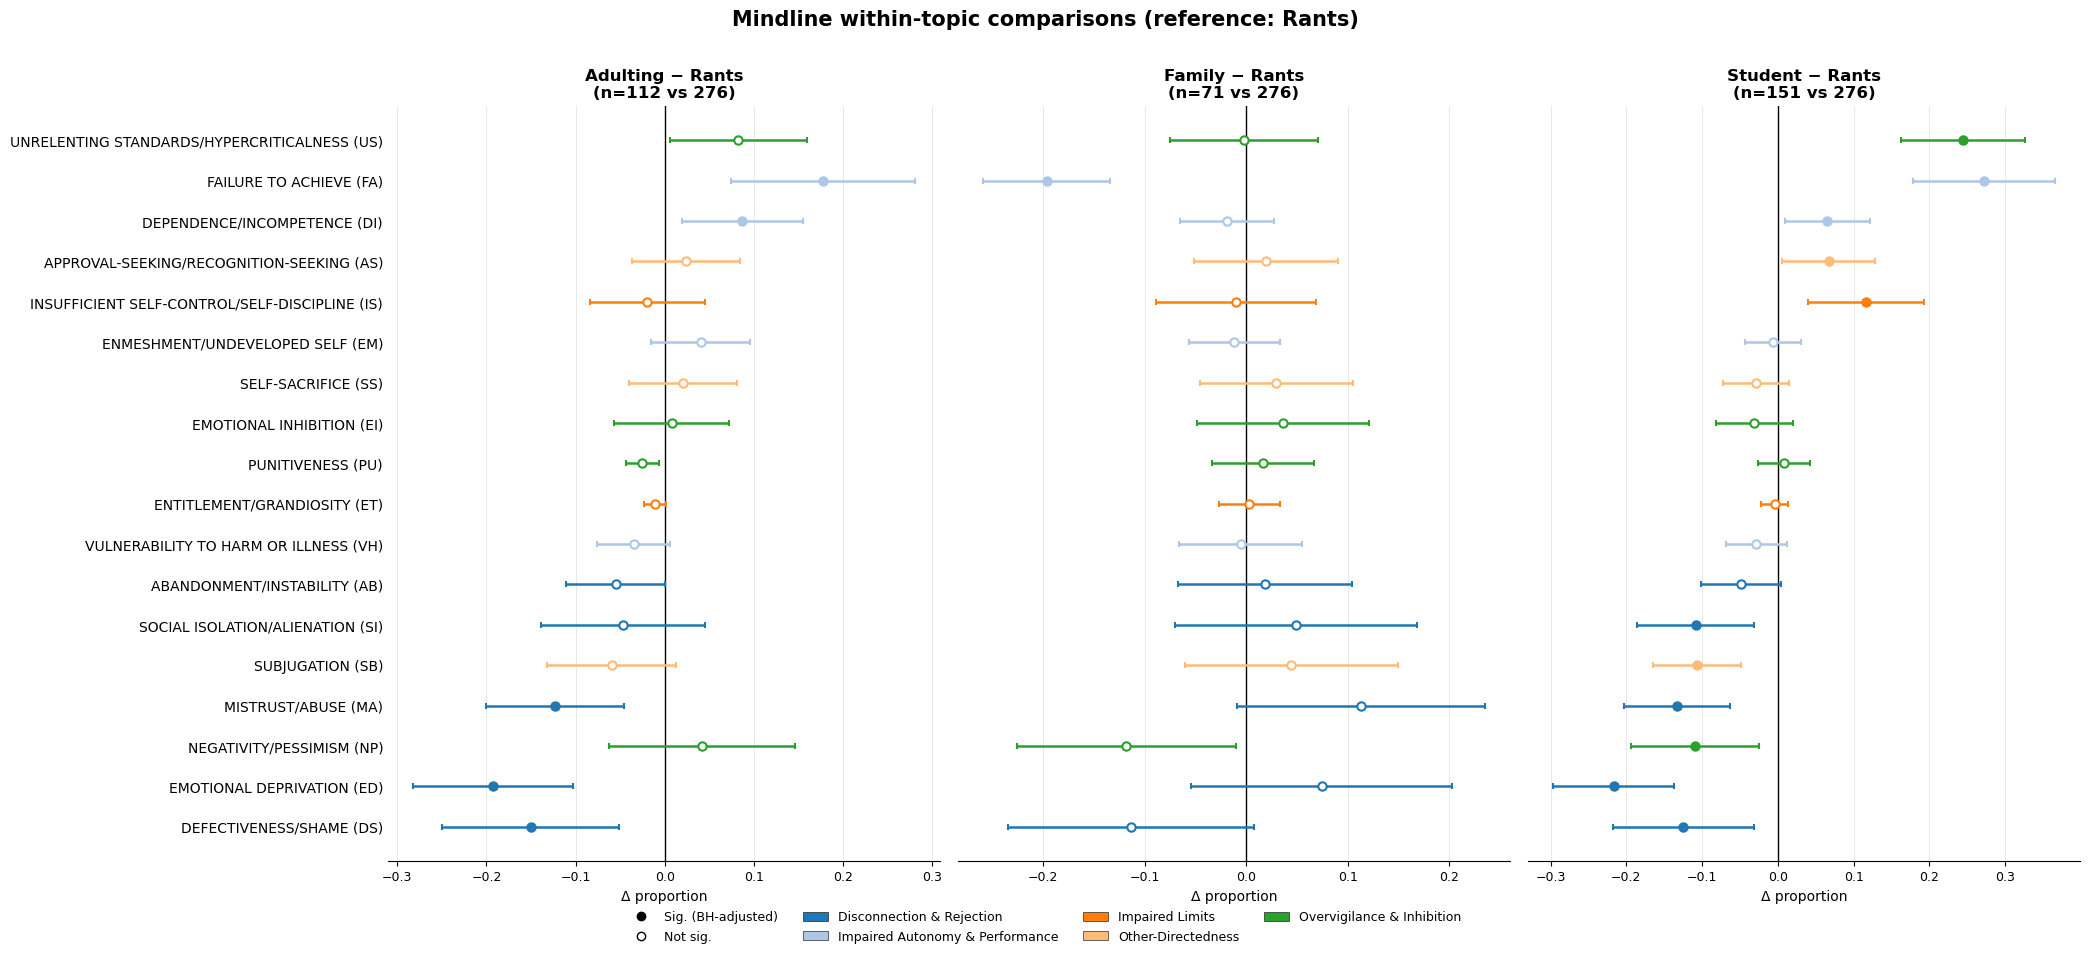

  → saved panel grid plot (reference=Rants)


OPTION 3: Heatmap of all pairwise differences


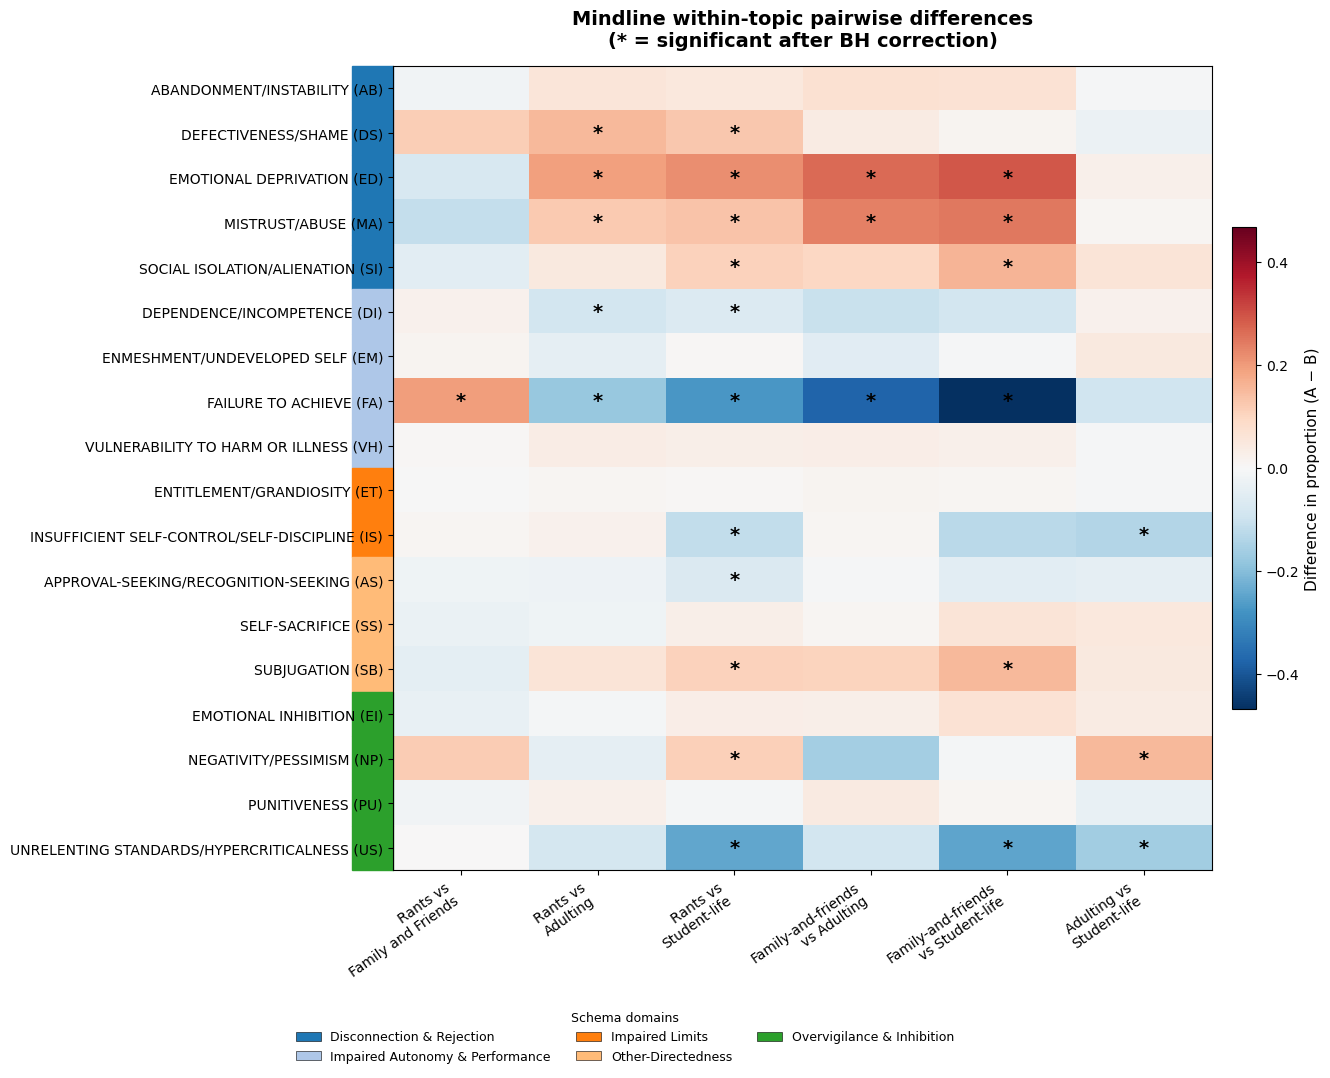

  → saved heatmap plot


In [ ]:
"""
Within-Mindline topic comparisons
──────────────────────────────────
Compare schema proportions across four Mindline topics:
  Rants  vs  Family and Friends  vs  Adulting  vs  Student Life

For every pair of topics we run the same two-proportion z-test
(+ BH correction) used in the cross-platform analysis, and
produce the same style of difference plot.
"""

import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2_contingency

# =========================================================
# 1) LOAD & PREP  (mirrors the original notebook)
# =========================================================

df_mindline = pd.read_csv("stlabels_extracted/stlabels/mindline/hangouts_gemini_3labels.csv")
df_mindline_with_topics = pd.read_csv("stlabels_extracted/stlabels/mindline/mindline_hangouts.csv")
df_mindline_with_topics = df_mindline_with_topics[["pid", "type"]]
df_mindline_with_topics["pid"] = df_mindline_with_topics["pid"].astype(str)
df_mindline["pid"] = df_mindline["pid"].astype(str)
df_mindline = pd.merge(df_mindline, df_mindline_with_topics, on="pid", how="left").reset_index(drop=True)
df_mindline = df_mindline.rename(columns={"type": "topic"})

# ── schema standardisation ──
schema_map = {
    "NEGATIVITY/PESSIMISM": "NEGATIVITY/PESSIMISM (NP)",
    "NEGATIVITY/PESSIMISM (NP)": "NEGATIVITY/PESSIMISM (NP)",
    "EMOTIONAL DEPRIVATION": "EMOTIONAL DEPRIVATION (ED)",
    "EMOTIONAL DEPRIVATION (ED)": "EMOTIONAL DEPRIVATION (ED)",
    "DEFECTIVENESS/SHAME": "DEFECTIVENESS/SHAME (DS)",
    "DEFECTIVENESS/SHAME (DS)": "DEFECTIVENESS/SHAME (DS)",
    "SOCIAL ISOLATION/ALIENATION": "SOCIAL ISOLATION/ALIENATION (SI)",
    "SOCIAL ISOLATION/ALIENATION (SI)": "SOCIAL ISOLATION/ALIENATION (SI)",
    "INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE": "INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS)",
    "INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS)": "INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS)",
    "EMOTIONAL INHIBITION": "EMOTIONAL INHIBITION (EI)",
    "EMOTIONAL INHIBITION (EI)": "EMOTIONAL INHIBITION (EI)",
    "DEPENDENCE/INCOMPETENCE": "DEPENDENCE/INCOMPETENCE (DI)",
    "DEPENDENCE/INCOMPETENCE (DI)": "DEPENDENCE/INCOMPETENCE (DI)",
    "MISTRUST/ABUSE": "MISTRUST/ABUSE (MA)",
    "MISTRUST/ABUSE (MA)": "MISTRUST/ABUSE (MA)",
    "FAILURE TO ACHIEVE": "FAILURE TO ACHIEVE (FA)",
    "FAILURE TO ACHIEVE (FA)": "FAILURE TO ACHIEVE (FA)",
    "ENMESHMENT/UNDEVELOPED SELF": "ENMESHMENT/UNDEVELOPED SELF (EM)",
    "ENMESHMENT/UNDEVELOPED SELF (EM)": "ENMESHMENT/UNDEVELOPED SELF (EM)",
    "SUBJUGATION": "SUBJUGATION (SB)",
    "SUBJUGATION (SB)": "SUBJUGATION (SB)",
    "UNRELENTING STANDARDS": "UNRELENTING STANDARDS/HYPERCRITICALNESS (US)",
    "UNRELENTING STANDARDS (US)": "UNRELENTING STANDARDS/HYPERCRITICALNESS (US)",
    "UNRELENTING STANDARDS/HYPERCRITICALNESS (US)": "UNRELENTING STANDARDS/HYPERCRITICALNESS (US)",
    "VULNERABILITY TO HARM OR ILLNESS": "VULNERABILITY TO HARM OR ILLNESS (VH)",
    "VULNERABILITY TO HARM OR ILLNESS (VH)": "VULNERABILITY TO HARM OR ILLNESS (VH)",
    "SELF-SACRIFICE": "SELF-SACRIFICE (SS)",
    "SELF-SACRIFICE (SS)": "SELF-SACRIFICE (SS)",
    "APPROVAL-SEEKING/RECOGNITION-SEEKING": "APPROVAL-SEEKING/RECOGNITION-SEEKING (AS)",
    "APPROVAL-SEEKING/RECOGNITION-SEEKING (AS)": "APPROVAL-SEEKING/RECOGNITION-SEEKING (AS)",
    "ABANDONMENT/INSTABILITY": "ABANDONMENT/INSTABILITY (AB)",
    "ABANDONMENT/INSTABILITY (AB)": "ABANDONMENT/INSTABILITY (AB)",
    "PUNITIVENESS": "PUNITIVENESS (PU)",
    "PUNITIVENESS (PU)": "PUNITIVENESS (PU)",
    "ENTITLEMENT/GRANDIOSITY": "ENTITLEMENT/GRANDIOSITY (ET)",
    "ENTITLEMENT/GRANDIOSITY (ET)": "ENTITLEMENT/GRANDIOSITY (ET)",
}

ems_cols_m = ["label1", "label2", "label3"]

dfm_long = (
    df_mindline
    .melt(id_vars=["pid", "topic"], value_vars=ems_cols_m, value_name="schema")
    .dropna(subset=["schema"])
    .copy()
)
dfm_long["schema"] = dfm_long["schema"].replace(schema_map)

# =========================================================
# 2) DOMAIN MAPPING  (identical to original)
# =========================================================

schema_domain_map = {
    "ABANDONMENT/INSTABILITY (AB)": "Disconnection & Rejection",
    "MISTRUST/ABUSE (MA)": "Disconnection & Rejection",
    "EMOTIONAL DEPRIVATION (ED)": "Disconnection & Rejection",
    "DEFECTIVENESS/SHAME (DS)": "Disconnection & Rejection",
    "SOCIAL ISOLATION/ALIENATION (SI)": "Disconnection & Rejection",
    "DEPENDENCE/INCOMPETENCE (DI)": "Impaired Autonomy & Performance",
    "VULNERABILITY TO HARM OR ILLNESS (VH)": "Impaired Autonomy & Performance",
    "ENMESHMENT/UNDEVELOPED SELF (EM)": "Impaired Autonomy & Performance",
    "FAILURE TO ACHIEVE (FA)": "Impaired Autonomy & Performance",
    "ENTITLEMENT/GRANDIOSITY (ET)": "Impaired Limits",
    "INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS)": "Impaired Limits",
    "SUBJUGATION (SB)": "Other-Directedness",
    "SELF-SACRIFICE (SS)": "Other-Directedness",
    "APPROVAL-SEEKING/RECOGNITION-SEEKING (AS)": "Other-Directedness",
    "NEGATIVITY/PESSIMISM (NP)": "Overvigilance & Inhibition",
    "EMOTIONAL INHIBITION (EI)": "Overvigilance & Inhibition",
    "UNRELENTING STANDARDS/HYPERCRITICALNESS (US)": "Overvigilance & Inhibition",
    "PUNITIVENESS (PU)": "Overvigilance & Inhibition",
}

domain_order = [
    "Disconnection & Rejection",
    "Impaired Autonomy & Performance",
    "Impaired Limits",
    "Other-Directedness",
    "Overvigilance & Inhibition",
]

cmap = plt.get_cmap("tab20")
domain_colors = {d: cmap(i) for i, d in enumerate(domain_order)}

# =========================================================
# 3) TOPICS TO COMPARE
# =========================================================

topics = ["Rants", "Family and Friends", "Adulting", "Student Life"]

# Short labels for filenames / titles
short = {
    "Rants": "Rants",
    "Family and Friends": "Family",
    "Adulting": "Adulting",
    "Student Life": "Student",
}

# =========================================================
# 4) HELPER: pairwise z-test  (same logic as get_z_tests)
# =========================================================

def pairwise_z_tests(df_long_a, df_long_b, label_a, label_b):
    """Run per-schema two-proportion z-tests between two topic subsets."""

    df_long_a = df_long_a.copy()
    df_long_b = df_long_b.copy()
    df_long_a["group"] = label_a
    df_long_b["group"] = label_b

    df_long = pd.concat([df_long_a, df_long_b], ignore_index=True)

    # binary post × schema matrix
    binary = (
        df_long.assign(present=1)
        .pivot_table(
            index=["group", "pid"],
            columns="schema",
            values="present",
            aggfunc="max",
            fill_value=0,
        )
        .reset_index()
    )

    bin_a = binary[binary["group"] == label_a]
    bin_b = binary[binary["group"] == label_b]
    n_a = len(bin_a)
    n_b = len(bin_b)

    schema_cols = [c for c in binary.columns if c not in ["group", "pid"]]

    rows = []
    for s in schema_cols:
        c_a = int(bin_a[s].sum())
        c_b = int(bin_b[s].sum())
        z, p = proportions_ztest([c_a, c_b], [n_a, n_b])
        rows.append({
            "schema": s,
            f"count_{label_a}": c_a,
            f"count_{label_b}": c_b,
            f"prop_{label_a}": c_a / n_a,
            f"prop_{label_b}": c_b / n_b,
            "diff": (c_a / n_a) - (c_b / n_b),
            "z": z,
            "p": p,
        })

    res = pd.DataFrame(rows)
    res["p_adj"] = multipletests(res["p"], method="fdr_bh")[1]
    res = res.sort_values(["p_adj", "p", "schema"]).reset_index(drop=True)
    res["p_reject"] = res["p_adj"] < 0.05

    # chi-square omnibus
    table = pd.crosstab(df_long["group"], df_long["schema"])
    chi2, p_global, dof, _ = chi2_contingency(table)
    chi_res = {"comparison": f"{label_a} vs {label_b}",
               "Chi2": chi2, "p": p_global, "dof": dof}

    return res, chi_res, n_a, n_b


# =========================================================
# 5) HELPER: difference plot  (same style as plot_differences)
# =========================================================

def plot_pairwise(results, label_a, label_b, n_a, n_b, plot_name):
    """Produce the same lollipop/error-bar plot as the original code."""

    plot_df = results.copy()

    # diff = prop_b − prop_a  (positive means label_b is higher)
    plot_df["diff_rev"] = plot_df[f"prop_{label_b}"] - plot_df[f"prop_{label_a}"]

    plot_df["se"] = np.sqrt(
        plot_df[f"prop_{label_b}"] * (1 - plot_df[f"prop_{label_b}"]) / n_b
        + plot_df[f"prop_{label_a}"] * (1 - plot_df[f"prop_{label_a}"]) / n_a
    )
    plot_df["ci95"] = 1.96 * plot_df["se"]
    plot_df["sig_adj"] = plot_df["p_adj"] < 0.05

    plot_df["domain"] = plot_df["schema"].map(schema_domain_map)
    plot_df["color"] = plot_df["domain"].map(domain_colors).fillna("#7f7f7f")

    plot_df = plot_df.sort_values("diff_rev").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(18, 8.5))
    y = np.arange(len(plot_df))

    for i, row in enumerate(plot_df.itertuples()):
        ax.errorbar(
            x=row.diff_rev, y=i, xerr=row.ci95,
            fmt="o", color=row.color, ecolor=row.color,
            elinewidth=2, capsize=3, capthick=1.5, markersize=7,
            markerfacecolor=row.color if row.sig_adj else "white",
            markeredgecolor=row.color, markeredgewidth=1.8, zorder=3,
        )

    ax.axvline(0, color="black", linewidth=1.3)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["schema"], fontsize=11)
    ax.set_xlabel(
        f"Difference in proportion of posts ({label_b} − {label_a})",
        fontsize=12,
    )
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.8, alpha=0.7)
    ax.grid(axis="y", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", labelsize=11)

    xmin = (plot_df["diff_rev"] - plot_df["ci95"]).min() - 0.01
    xmax = (plot_df["diff_rev"] + plot_df["ci95"]).max() + 0.01
    ax.set_xlim(xmin, xmax)

    ax.text(0.2, 0.995, f"← {label_a} higher ←",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=11)
    ax.text(0.9, 0.995, f"→ {label_b} higher →",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=11)

    # significance legend
    sig_legend = [
        Line2D([0], [0], marker="o", color="black",
               markerfacecolor="black", markersize=7, linewidth=0,
               label="Significant after BH adjustment"),
        Line2D([0], [0], marker="o", color="black",
               markerfacecolor="white", markersize=7, linewidth=0,
               label="Not significant after BH adjustment"),
    ]
    ax.legend(handles=sig_legend, loc="lower right", frameon=True,
              edgecolor="none", fontsize=10)

    # domain legend
    domain_handles = [
        Patch(facecolor=domain_colors[d], edgecolor="black",
              linewidth=0.4, label=d)
        for d in domain_order
    ]
    fig.legend(handles=domain_handles, title="Schema domains",
               loc="lower center", bbox_to_anchor=(0.5, -0.02),
               ncol=len(domain_handles), frameon=True, edgecolor="none",
               fontsize=10, title_fontsize=10)

    plt.subplots_adjust(left=0.33, right=0.97, top=0.92, bottom=0.18)

    ax.set_title(
        f"Mindline: {label_a} (n={n_a}) vs {label_b} (n={n_b})",
        fontsize=14, fontweight="bold", pad=12,
    )

    os.makedirs("plots/mindline_topic_comparisons", exist_ok=True)
    plt.savefig(
        f"plots/mindline_topic_comparisons/{plot_name}.png",
        dpi=900, bbox_inches="tight",
    )
    plt.show()
    print(f"  → saved plots/mindline_topic_comparisons/{plot_name}.png")


# =========================================================
# 6) RUN ALL PAIRWISE COMPARISONS
# =========================================================

all_z_results = []
all_chi_results = []

pairs = list(itertools.combinations(topics, 2))

print(f"\n{'='*60}")
print(f"Running {len(pairs)} pairwise comparisons within Mindline")
print(f"{'='*60}\n")

for t_a, t_b in pairs:
    lab_a = short[t_a]
    lab_b = short[t_b]

    df_a = dfm_long[dfm_long["topic"] == t_a].reset_index(drop=True)
    df_b = dfm_long[dfm_long["topic"] == t_b].reset_index(drop=True)

    if df_a.empty or df_b.empty:
        print(f"⚠  Skipping {lab_a} vs {lab_b}: one group is empty")
        continue

    res, chi, n_a, n_b = pairwise_z_tests(df_a, df_b, lab_a, lab_b)

    print(f"\n── {lab_a} (n={n_a}) vs {lab_b} (n={n_b}) ──")
    print(f"   Chi²={chi['Chi2']:.2f}, p={chi['p']:.4g}, dof={chi['dof']}")
    sig_count = res["p_reject"].sum()
    print(f"   Schemas significant after BH: {sig_count}/{len(res)}")

    res["comparison"] = f"{lab_a} vs {lab_b}"
    all_z_results.append(res)
    all_chi_results.append(chi)

    fname = f"{lab_a}_vs_{lab_b}"
    plot_pairwise(res, lab_a, lab_b, n_a, n_b, fname)

# =========================================================
# 7) SAVE COMBINED RESULTS
# =========================================================

os.makedirs("data_for_OSF_upload/results", exist_ok=True)

combined_z = pd.concat(all_z_results, ignore_index=True)
combined_z.to_csv(
    "data_for_OSF_upload/results/mindline_topic_pairwise_z_tests.csv",
    index=False,
)

combined_chi = pd.DataFrame(all_chi_results)
combined_chi.to_csv(
    "data_for_OSF_upload/results/mindline_topic_pairwise_chi_square.csv",
    index=False,
)

print(f"\n{'='*60}")
print("All results saved.")
print(f"  z-tests  → data_for_OSF_upload/results/mindline_topic_pairwise_z_tests.csv")
print(f"  chi²     → data_for_OSF_upload/results/mindline_topic_pairwise_chi_square.csv")
print(f"  plots    → plots/mindline_topic_comparisons/")
print(f"{'='*60}")

# =========================================================
# 8) SUMMARY TABLE
# =========================================================

print("\n\nChi-square omnibus results per pair:")
print(combined_chi.to_string(index=False))

print("\n\nSignificant schemas per comparison:")
for comp, grp in combined_z.groupby("comparison"):
    sig = grp[grp["p_reject"]]
    print(f"\n{comp}  ({len(sig)} significant):")
    if len(sig):
        print(sig[["schema", "diff", "z", "p_adj"]].to_string(index=False))
    else:
        print("  (none)")


# =========================================================
# 9) OPTION 2 — PANEL GRID (fixed reference = Rants)
# =========================================================
#
# Three subplots side-by-side, all showing "Topic X − Rants".
# Shared y-axis so schemas line up across panels.
# =========================================================

def plot_panel_grid(combined_z, reference="Rants"):
    """3-panel figure: each panel = one topic vs the reference."""

    # filter to comparisons that include the reference
    ref_comps = combined_z[
        combined_z["comparison"].str.contains(reference)
    ].copy()

    comp_names = sorted(ref_comps["comparison"].unique())

    if len(comp_names) == 0:
        print(f"No comparisons found involving '{reference}'")
        return

    # we need a consistent schema order across panels — sort by
    # mean absolute difference so the most interesting schemas are
    # visually prominent
    all_schemas = sorted(ref_comps["schema"].unique())

    # for each comparison, compute diff as "other − reference"
    panel_data = {}
    for comp in comp_names:
        cdf = ref_comps[ref_comps["comparison"] == comp].copy()

        # figure out which label is the reference and which is the other
        parts = comp.split(" vs ")
        label_a, label_b = parts[0], parts[1]

        # we want diff = other − reference
        if label_a == reference:
            other = label_b
            cdf["diff_plot"] = cdf[f"prop_{label_b}"] - cdf[f"prop_{label_a}"]
            n_ref = cdf[f"count_{label_a}"].sum()  # approximate
            n_other = cdf[f"count_{label_b}"].sum()
            # recompute properly from the results columns
            prop_ref_col = f"prop_{label_a}"
            prop_other_col = f"prop_{label_b}"
        else:
            other = label_a
            cdf["diff_plot"] = cdf[f"prop_{label_a}"] - cdf[f"prop_{label_b}"]
            prop_ref_col = f"prop_{label_b}"
            prop_other_col = f"prop_{label_a}"

        cdf["other_label"] = other
        panel_data[other] = cdf

    # fixed schema order: sort by mean diff across panels for readability
    schema_mean_diff = {}
    for s in all_schemas:
        diffs = []
        for other, cdf in panel_data.items():
            row = cdf[cdf["schema"] == s]
            if not row.empty:
                diffs.append(row["diff_plot"].values[0])
        schema_mean_diff[s] = np.mean(diffs) if diffs else 0

    sorted_schemas = sorted(all_schemas, key=lambda s: schema_mean_diff[s])

    # create figure
    n_panels = len(panel_data)
    fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 9),
                              sharey=True)
    if n_panels == 1:
        axes = [axes]

    for ax_i, (other, cdf) in enumerate(
        sorted(panel_data.items(), key=lambda x: x[0])
    ):
        ax = axes[ax_i]

        # reorder cdf to match sorted_schemas
        cdf = cdf.set_index("schema").reindex(sorted_schemas).reset_index()

        y = np.arange(len(cdf))

        # compute SE and CI
        # We need n_ref and n_other — pull from the comparison
        comp = cdf["comparison"].iloc[0]
        parts = comp.split(" vs ")
        label_a, label_b = parts[0], parts[1]

        if label_a == reference:
            prop_ref_col = f"prop_{label_a}"
            prop_other_col = f"prop_{label_b}"
        else:
            prop_ref_col = f"prop_{label_b}"
            prop_other_col = f"prop_{label_a}"

        # get n from the pairwise results we already ran
        # re-derive from the comparison data
        df_ref_topic = dfm_long[dfm_long["topic"] == reference]
        df_other_topic = dfm_long[dfm_long["topic"] ==
            [k for k, v in short.items() if v == other][0]
            if other in short.values()
            else other
        ]

        # get unique post counts
        n_ref = df_ref_topic["pid"].nunique()
        n_oth = df_other_topic["pid"].nunique()

        cdf["se"] = np.sqrt(
            cdf[prop_other_col] * (1 - cdf[prop_other_col]) / n_oth
            + cdf[prop_ref_col] * (1 - cdf[prop_ref_col]) / n_ref
        )
        cdf["ci95"] = 1.96 * cdf["se"]
        cdf["sig_adj"] = cdf["p_adj"] < 0.05

        cdf["domain"] = cdf["schema"].map(schema_domain_map)
        cdf["color"] = cdf["domain"].map(domain_colors).fillna("#7f7f7f")

        for row_i, row in enumerate(cdf.itertuples()):
            ax.errorbar(
                x=row.diff_plot, y=row_i, xerr=row.ci95,
                fmt="o", color=row.color, ecolor=row.color,
                elinewidth=1.8, capsize=2.5, capthick=1.2, markersize=6,
                markerfacecolor=row.color if row.sig_adj else "white",
                markeredgecolor=row.color, markeredgewidth=1.5, zorder=3,
            )

        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(f"{other} − {reference}\n(n={n_oth} vs {n_ref})",
                      fontsize=12, fontweight="bold")
        ax.set_xlabel("Δ proportion", fontsize=10)
        ax.grid(axis="x", color="#D9D9D9", linewidth=0.6, alpha=0.7)
        ax.grid(axis="y", visible=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", length=0)
        ax.tick_params(axis="x", labelsize=9)

    # y-axis labels only on leftmost panel
    axes[0].set_yticks(np.arange(len(sorted_schemas)))
    axes[0].set_yticklabels(sorted_schemas, fontsize=10)

    # shared legends
    sig_legend = [
        Line2D([0], [0], marker="o", color="black",
               markerfacecolor="black", markersize=6, linewidth=0,
               label="Sig. (BH-adjusted)"),
        Line2D([0], [0], marker="o", color="black",
               markerfacecolor="white", markersize=6, linewidth=0,
               label="Not sig."),
    ]

    domain_handles = [
        Patch(facecolor=domain_colors[d], edgecolor="black",
              linewidth=0.4, label=d)
        for d in domain_order
    ]

    fig.legend(handles=sig_legend + domain_handles,
               loc="lower center", bbox_to_anchor=(0.5, -0.04),
               ncol=4, frameon=True, edgecolor="none",
               fontsize=9, title_fontsize=9)

    fig.suptitle(f"Mindline within-topic comparisons (reference: {reference})",
                 fontsize=15, fontweight="bold", y=1.01)

    plt.tight_layout()

    os.makedirs("plots/mindline_topic_comparisons", exist_ok=True)
    plt.savefig(
        f"plots/mindline_topic_comparisons/panel_grid_ref_{reference}.png",
        dpi=900, bbox_inches="tight",
    )
    plt.show()
    print(f"  → saved panel grid plot (reference={reference})")


print("\n\n" + "=" * 60)
print("OPTION 2: Panel grid (reference = Rants)")
print("=" * 60)
plot_panel_grid(combined_z, reference="Rants")


# =========================================================
# 10) OPTION 3 — HEATMAP OF ALL PAIRWISE DIFFERENCES
# =========================================================
#
# Rows = schemas (18), Columns = pairwise comparisons (6)
# Color = difference in proportion (diverging colormap)
# Asterisks = significant after BH correction
# =========================================================

def plot_heatmap(combined_z):
    """Heatmap: schemas × comparisons, color = diff, * = significant."""

    import matplotlib.colors as mcolors

    # Build the matrix — explicit column order
    desired_order = [
        "Rants vs Family",
        "Rants vs Adulting",
        "Rants vs Student",
        "Family vs Adulting",
        "Family vs Student",
        "Adulting vs Student",
    ]

    # keep only comparisons that exist in the data, in the desired order
    available = set(combined_z["comparison"].unique())
    comps = [c for c in desired_order if c in available]
    # fallback: if naming doesn't match, append any remaining
    for c in sorted(available):
        if c not in comps:
            comps.append(c)

    all_schemas = sorted(combined_z["schema"].unique())

    diff_matrix = pd.DataFrame(index=all_schemas, columns=comps, dtype=float)
    sig_matrix = pd.DataFrame(index=all_schemas, columns=comps, dtype=bool)

    for comp in comps:
        cdf = combined_z[combined_z["comparison"] == comp]
        for _, row in cdf.iterrows():
            diff_matrix.loc[row["schema"], comp] = row["diff"]
            sig_matrix.loc[row["schema"], comp] = row["p_reject"]

    diff_matrix = diff_matrix.fillna(0).astype(float)
    sig_matrix = sig_matrix.fillna(False)

    # Sort schemas by domain then name for visual grouping
    diff_matrix["domain"] = diff_matrix.index.map(schema_domain_map)
    diff_matrix["domain_rank"] = diff_matrix["domain"].map(
        {d: i for i, d in enumerate(domain_order)}
    )
    diff_matrix["_schema"] = diff_matrix.index
    diff_matrix = diff_matrix.sort_values(["domain_rank", "_schema"])
    diff_matrix = diff_matrix.drop(columns=["_schema"])
    domain_col = diff_matrix["domain"].copy()
    diff_matrix = diff_matrix.drop(columns=["domain", "domain_rank"])

    sig_matrix = sig_matrix.reindex(diff_matrix.index)

    # figure
    fig, ax = plt.subplots(figsize=(14, 10))

    vmax = np.abs(diff_matrix.values).max()
    vmax = max(vmax, 0.01)  # avoid degenerate case

    im = ax.imshow(
        diff_matrix.values,
        cmap="RdBu_r",
        aspect="auto",
        vmin=-vmax, vmax=vmax,
        interpolation="nearest",
    )

    # asterisks for significance
    for i in range(len(diff_matrix)):
        for j in range(len(comps)):
            if sig_matrix.iloc[i, j]:
                ax.text(j, i, "*", ha="center", va="center",
                        fontsize=14, fontweight="bold", color="black")

    # labels
    display_labels = {
        "Rants vs Family":    "Rants vs\nFamily and Friends",
        "Rants vs Adulting":  "Rants vs\nAdulting",
        "Rants vs Student":   "Rants vs\nStudent-life",
        "Family vs Adulting": "Family-and-friends\nvs Adulting",
        "Family vs Student":  "Family-and-friends\nvs Student-life",
        "Adulting vs Student":"Adulting vs\nStudent-life",
    }
    x_labels = [display_labels.get(c, c) for c in comps]

    ax.set_xticks(np.arange(len(comps)))
    ax.set_xticklabels(x_labels, fontsize=10, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(diff_matrix)))
    ax.set_yticklabels(diff_matrix.index, fontsize=10)

    # domain color bar on the left
    for i, schema in enumerate(diff_matrix.index):
        d = domain_col.loc[schema]
        c = domain_colors.get(d, "#7f7f7f")
        ax.add_patch(plt.Rectangle((-0.8, i - 0.5), 0.3, 1,
                                    color=c, clip_on=False))

    # colorbar
    cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label("Difference in proportion (A − B)", fontsize=11)

    # domain legend
    domain_handles = [
        Patch(facecolor=domain_colors[d], edgecolor="black",
              linewidth=0.4, label=d)
        for d in domain_order
    ]
    fig.legend(handles=domain_handles, title="Schema domains",
               loc="lower center", bbox_to_anchor=(0.45, -0.08),
               ncol=3, frameon=True, edgecolor="none",
               fontsize=9, title_fontsize=9)

    ax.set_title(
        "Mindline within-topic pairwise differences\n(* = significant after BH correction)",
        fontsize=14, fontweight="bold", pad=14,
    )

    plt.tight_layout()

    os.makedirs("plots/mindline_topic_comparisons", exist_ok=True)
    plt.savefig(
        "plots/mindline_topic_comparisons/heatmap_all_pairs.pdf",
        dpi=900, bbox_inches="tight",
    )
    plt.show()
    print("  → saved heatmap plot")


print("\n\n" + "=" * 60)
print("OPTION 3: Heatmap of all pairwise differences")
print("=" * 60)
plot_heatmap(combined_z)